# 01 — Raw Data Exploration

Exploratory analysis of the raw ingested data: session metadata and event-level telemetry.

In [13]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [14]:
sessions = pd.read_parquet(ROOT / "data/processed/sessions.parquet")
events   = pd.read_parquet(ROOT / "data/processed/events.parquet")

print(f"Sessions : {len(sessions)}")
print(f"Events   : {len(events):,}")
sessions

Sessions : 12
Events   : 434,067


,session_id,player,game,sensitivity,dpi,recorded_at,duration_ms,event_count,source_file
0,97e57c85,hydra,arc_raiders,0.45,800,2026-05-09 19:34:01.300406+00:00,65144.219,38468,20260509T193401_hydRa_arc_raiders_97e57c85.json
1,c299e04d,shotik,valorant,0.23,450,2026-05-16 05:26:20.174027+00:00,71840.207,40149,20260516T052620_shotik_valorant_c299e04d.json
2,49e9e1d4,royik,tarkov,0.35,710,2026-05-16 05:27:59.790364+00:00,67072.314,46015,20260516T052759_royik_tarkov_49e9e1d4.json
3,94b438eb,rwa,cs2,0.10,350,2026-05-16 05:29:32.738073+00:00,62908.950,32903,20260516T052932_Rwa_cs2_94b438eb.json
4,8054d31f,shotik,valorant,0.10,250,2026-05-16 05:34:01.235923+00:00,64379.115,39282,20260516T053401_shotik_valorant_8054d31f.json
5,f2aa1f08,shotik,valorant,0.10,250,2026-05-16 05:35:12.918288+00:00,61855.433,45654,20260516T053512_shotik_valorant_f2aa1f08.json
6,7f80d8fa,hydra,arc_raiders,0.45,380,2026-05-16 05:36:54.971418+00:00,62971.947,34645,20260516T053654_hydRa_arc_raiders_7f80d8fa.json
7,94bcc6ed,hydra,arc_raiders,0.45,380,2026-05-16 05:38:03.904577+00:00,61895.277,35267,20260516T053803_hydRa_arc_raiders_94bcc6ed.json
8,9e9f0de3,royik,cs2,0.38,710,2026-05-16 05:39:24.156983+00:00,61248.487,37295,20260516T053924_royik_cs2_9e9f0de3.json
9,932757e8,royik,tarkov,0.38,710,2026-05-16 05:40:39.105461+00:00,61364.006,30342,20260516T054039_royik_tarkov_932757e8.json


## Session overview

In [15]:
display(
    sessions[[
        "player", "game", "dpi", "sensitivity",
        "duration_ms", "event_count", "recorded_at"
    ]]
    .assign(duration_s=lambda d: (d["duration_ms"] / 1000).round(1))
    .drop(columns="duration_ms")
    .style.format({"event_count": "{:,}", "duration_s": "{:.1f}s"})
)

,player,game,dpi,sensitivity,event_count,recorded_at,duration_s
0,hydra,arc_raiders,800,0.450000,"38,468",2026-05-09 19:34:01.300406+00:00,65.1s
1,shotik,valorant,450,0.230000,"40,149",2026-05-16 05:26:20.174027+00:00,71.8s
2,royik,tarkov,710,0.350000,"46,015",2026-05-16 05:27:59.790364+00:00,67.1s
3,rwa,cs2,350,0.100000,"32,903",2026-05-16 05:29:32.738073+00:00,62.9s
4,shotik,valorant,250,0.100000,"39,282",2026-05-16 05:34:01.235923+00:00,64.4s
5,shotik,valorant,250,0.100000,"45,654",2026-05-16 05:35:12.918288+00:00,61.9s
6,hydra,arc_raiders,380,0.450000,"34,645",2026-05-16 05:36:54.971418+00:00,63.0s
7,hydra,arc_raiders,380,0.450000,"35,267",2026-05-16 05:38:03.904577+00:00,61.9s
8,royik,cs2,710,0.380000,"37,295",2026-05-16 05:39:24.156983+00:00,61.2s
9,royik,tarkov,710,0.380000,"30,342",2026-05-16 05:40:39.105461+00:00,61.4s


## Event type distribution

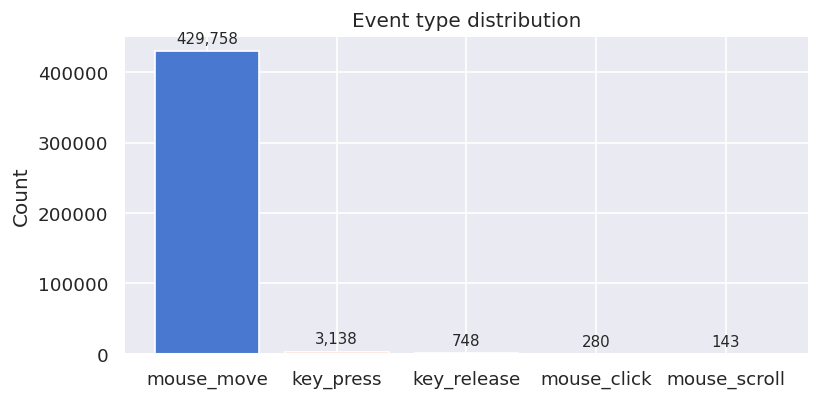

event_type
mouse_move      429758
key_press         3138
key_release        748
mouse_click        280
mouse_scroll       143


In [16]:
counts = events["event_type"].value_counts()

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(counts.index, counts.values, color=sns.color_palette("muted", len(counts)))
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=9)
ax.set_title("Event type distribution")
ax.set_ylabel("Count")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

print(counts.to_string())

## Mouse trajectory (first session)

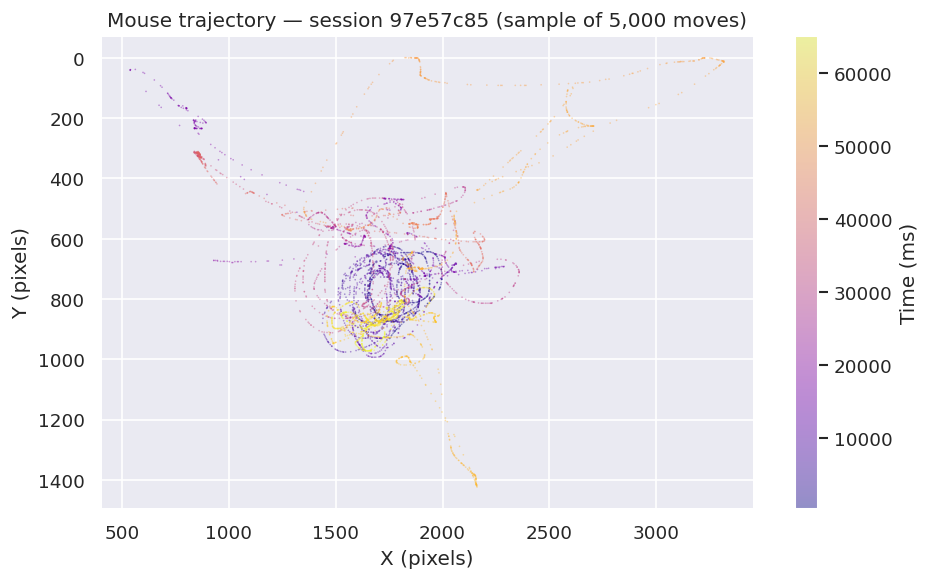

In [17]:
sid = sessions["session_id"].iloc[0]
mm = events[(events["session_id"] == sid) & (events["event_type"] == "mouse_move")].copy()
mm = mm.dropna(subset=["x", "y"])

# Downsample to at most 5000 points for rendering speed
if len(mm) > 5000:
    mm = mm.sample(5000, random_state=42).sort_values("t")

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    mm["x"].astype(float), mm["y"].astype(float),
    c=mm["t"].astype(float), cmap="plasma",
    s=1, alpha=0.4, linewidths=0,
)
plt.colorbar(sc, ax=ax, label="Time (ms)")
ax.invert_yaxis()  # screen coordinates: y=0 is top
ax.set_title(f"Mouse trajectory — session {sid} (sample of {len(mm):,} moves)")
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")
plt.tight_layout()
plt.show()

## Event timeline

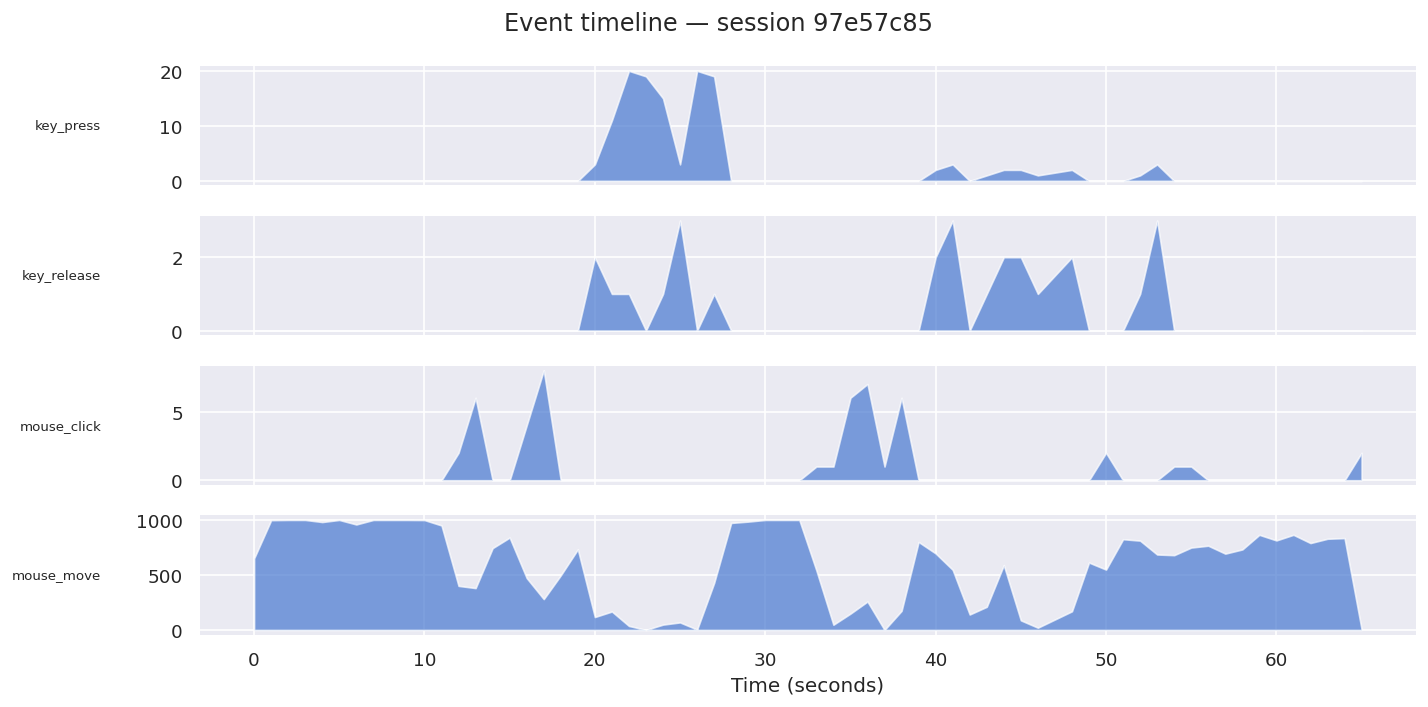

In [18]:
# Bin into 1-second buckets, count events per type per bucket
ev = events[events["session_id"] == sid].copy()
ev["second"] = (ev["t"] / 1000).astype(int)
timeline = (
    ev.groupby(["second", "event_type"])
    .size()
    .reset_index(name="count")
    .pivot(index="second", columns="event_type", values="count")
    .fillna(0)
)

fig, axes = plt.subplots(len(timeline.columns), 1, figsize=(12, 6), sharex=True)
if len(timeline.columns) == 1:
    axes = [axes]
for ax, col in zip(axes, timeline.columns):
    ax.fill_between(timeline.index, timeline[col], alpha=0.7, label=col)
    ax.set_ylabel(col, fontsize=8, rotation=0, ha="right", va="center")
    ax.yaxis.set_label_coords(-0.08, 0.5)
axes[-1].set_xlabel("Time (seconds)")
fig.suptitle(f"Event timeline — session {sid}")
plt.tight_layout()
plt.show()

## Keyboard key frequency

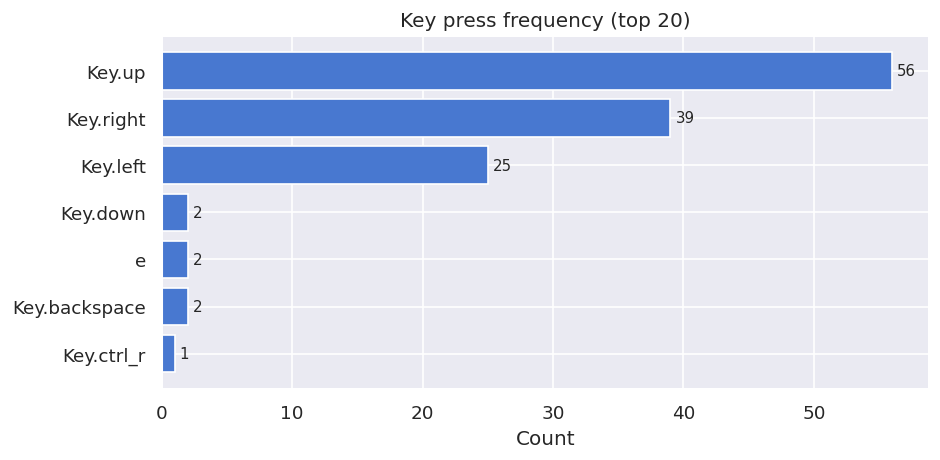

In [19]:
kp = events[
    (events["session_id"] == sid) & (events["event_type"] == "key_press")
].copy()

key_counts = (
    kp["key"].value_counts()
    .head(20)
    .reset_index()
    .rename(columns={"index": "key", "key": "count"})
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(key_counts.iloc[:, 0], key_counts.iloc[:, 1])
ax.bar_label(bars, padding=3, fontsize=9)
ax.invert_yaxis()
ax.set_title("Key press frequency (top 20)")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()